In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/train.csv')
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2860,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2861,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2862,6,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2863,8,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,1
pixel780,1
pixel781,1
pixel782,1


In [5]:
df['label'].value_counts()

,count
label,
1,329
2,316
6,292
0,290
7,285
4,284
9,283
5,276
8,261


In [6]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [7]:
max(x[2])

np.float64(255.0)

In [8]:
x=x/255
max(x[2])

np.float64(1.0)

In [9]:
import matplotlib.pyplot as plt

In [10]:
sample=df.sample(50)
pixel_val=sample.iloc[:,1:].values
pixel_val


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [11]:
actual_digits=sample.iloc[:,0].values
actual_digits

array([0, 2, 2, 3, 9, 2, 6, 4, 0, 7, 2, 2, 2, 5, 5, 0, 1, 1, 8, 0, 9, 1,
       5, 6, 1, 6, 5, 7, 9, 6, 3, 0, 3, 3, 6, 8, 0, 4, 8, 7, 1, 9, 3, 2,
       0, 5, 6, 3, 1, 9])

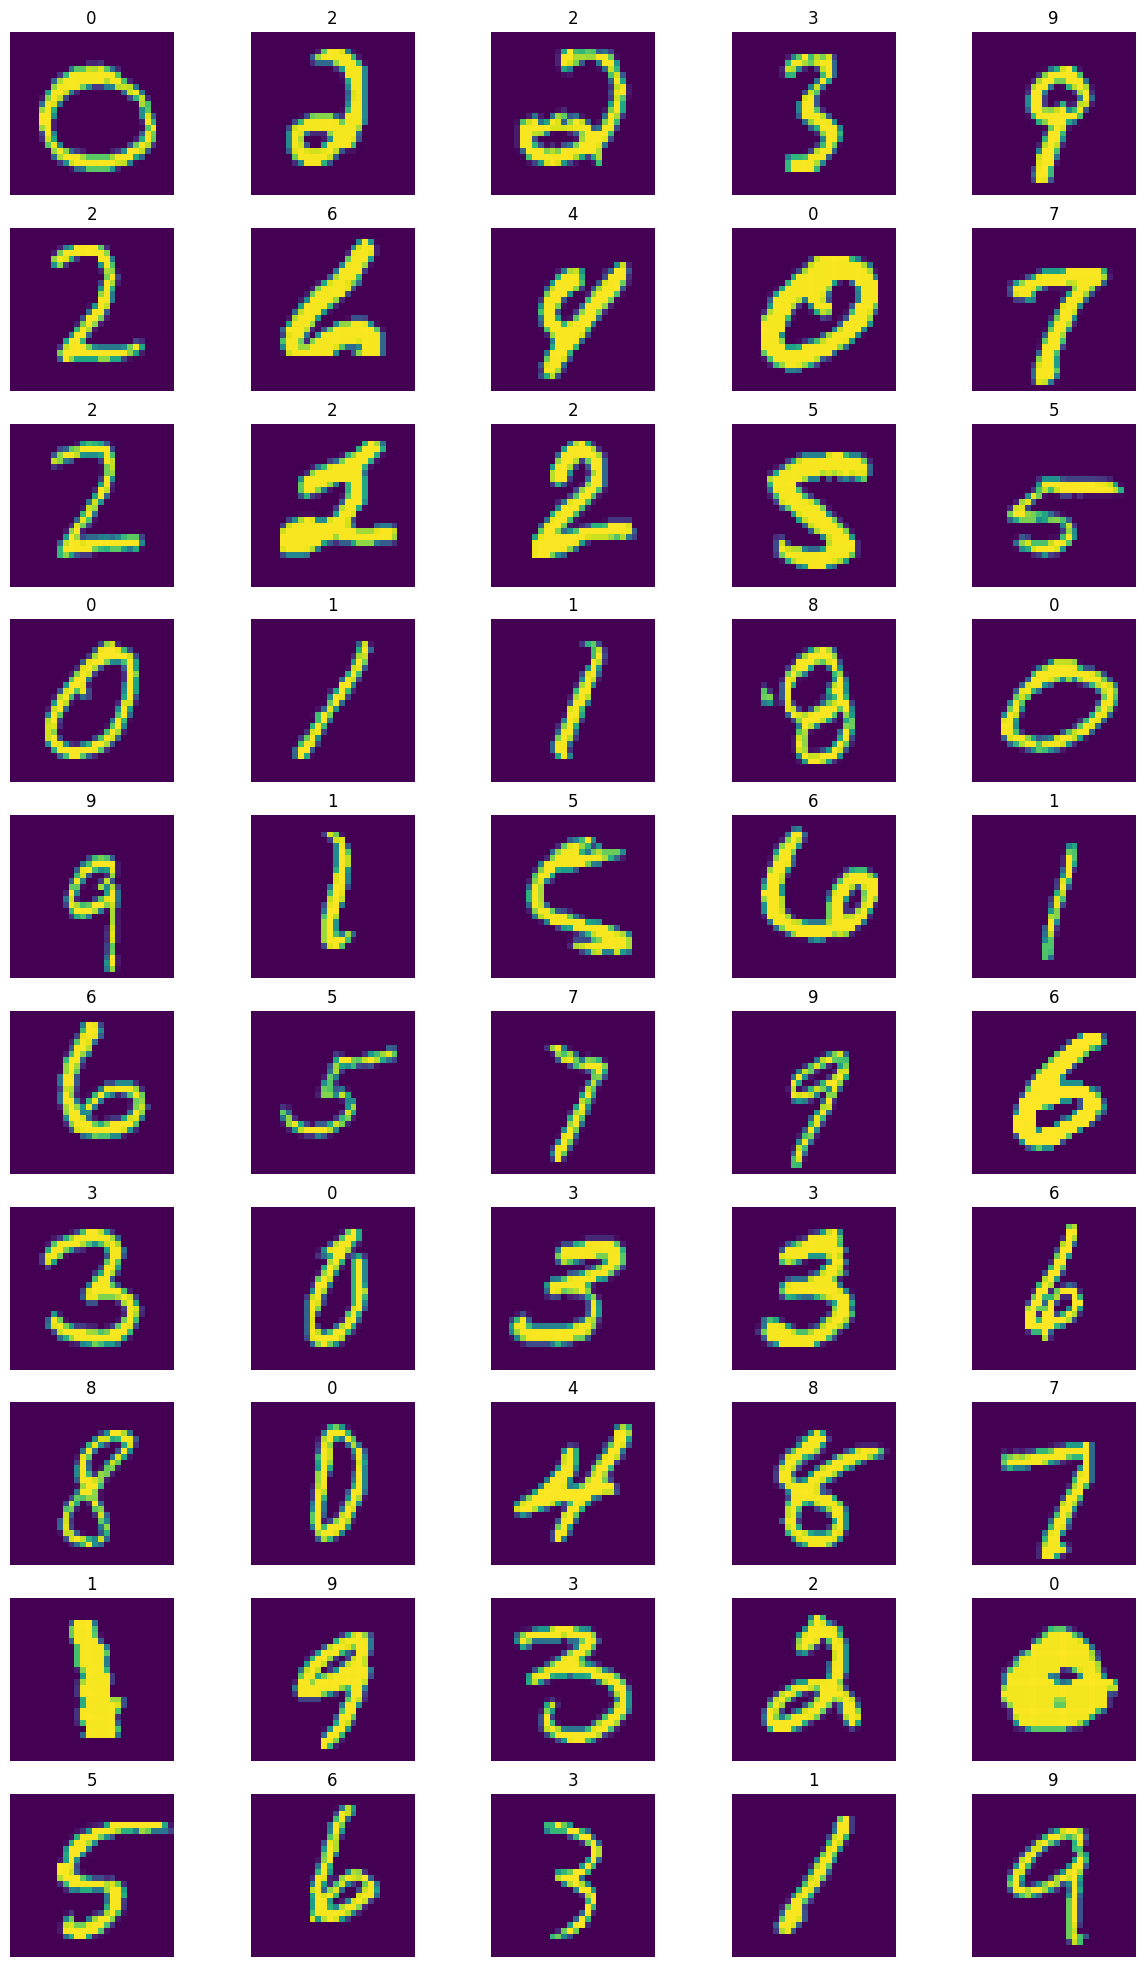

In [12]:
fig,axes=plt.subplots(10,5,figsize=(15,25))
for i in range(50):
    row=i//5
    col=i%5
    axes[row,col].imshow(pixel_val[i].reshape(28,28))
    axes[row,col].set_title(actual_digits[i])
    axes[row, col].axis('off')




In [13]:
from sklearn.model_selection import train_test_split


In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [15]:
print('x_train shape=',x_train.shape)
print('y_train shape=',y_train.shape)

x_train shape= (2292, 784)
y_train shape= (2292,)


In [16]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [17]:
model=Sequential()
model.add(Dense(75,activation='relu',input_dim=x_train.shape[1]))
model.add(Dense(50,activation='relu'))
model.add(Dense(20,activation='relu'))
model.add(Dense(10,activation='softmax'))

## Note - The number of nodes and activation functions are experimental, and the results can be significantly improved by identifying the most optimal parameters.
#I have determined these parameters through experimentation.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(loss='sparse_categorical_crossentropy',optimizer="Adam",metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 75)             │        58,875 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         3,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,905 (249.63 KB)

 Trainable params: 63,905 (249.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history=model.fit(x_train,y_train,epochs=15,batch_size=32,validation_split=0.2)

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.1630 - loss: nan - val_accuracy: 0.1089 - val_loss: nan
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1006 - loss: nan - val_accuracy: 0.1089 - val_loss: nan
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1051 - loss: nan - val_accuracy: 0.1089 - val_loss: nan
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1054 - loss: nan - val_accuracy: 0.1089 - val_loss: nan
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1048 - loss: nan - val_accuracy: 0.1089 - val_loss: nan
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1058 - loss: nan - val_accuracy: 0.1089 - val_loss: nan
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0954 - loss: nan - val_accuracy: 0.1089 - val_loss: nan
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1079 - loss: nan - val_accuracy: 0.1089 - val_loss: nan
Epoch 9/15
58/58 ━━━━━━━━━━━━━━━━━━━━

In [21]:
# this history contain the accuracy and loss along of each iteration
history.history

{'accuracy': [0.13311511278152466,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192,
  0.10420076549053192],
 'loss': [nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan],
 'val_accuracy': [0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511,
  0.10893246531486511],
 'val_loss': [nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan]}

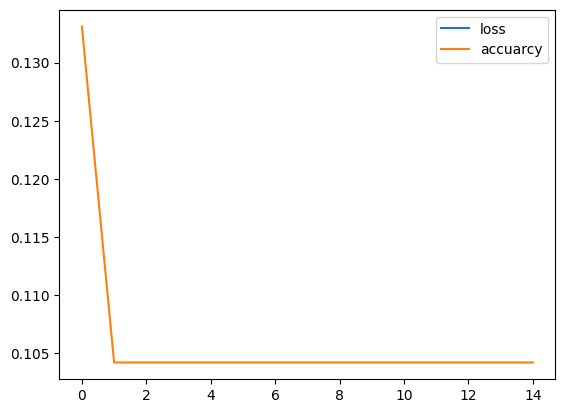

In [22]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['accuracy'],label='accuarcy')
plt.legend()
plt.show()

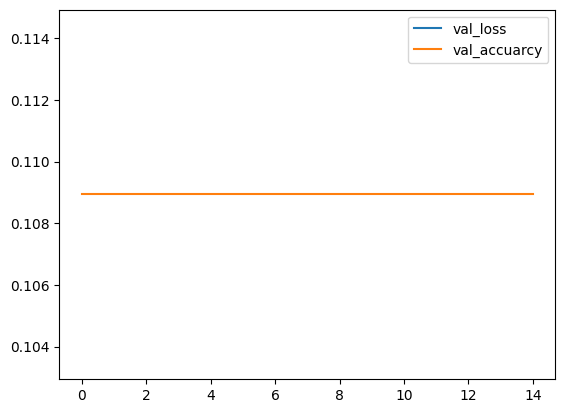

In [23]:
plt.plot(history.history['val_loss'],label='val_loss')
plt.plot(history.history['val_accuracy'],label='val_accuarcy')
plt.legend()
plt.show()